# GRAB Motifs and DNSM Selection Factors

This notebook examines how DNSM-inferred selection factors relate to known GRAB (Genomic Repertoire-wide Analysis of B cell) motifs in antibody heavy chain V genes. We restrict to sequences that are fully germline at all V gene sites to avoid confounding from somatic mutations.

**Analyses:**
1. **GRAB motif sites vs. background** — Where do GRAB motif sites fall relative to the background distribution of selection factors across all sites?
2. **Motif completeness** — How often are GRAB motifs fully intact vs. partially or fully mutated across V genes?
3. **Epistasis at intact sites** — When one site in a GRAB motif is mutated, does that change the selection pressure at the remaining intact sites? This tests whether GRAB motif sites exhibit epistatic interactions detectable by the DNSM.

**Key finding:** Selection factors at intact GRAB motif sites are largely similar regardless of whether the rest of the motif is intact or has one mutation, suggesting limited epistatic signal at the resolution of the DNSM.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from tqdm import tqdm

from dnsmex.local import localify
from utils import load_and_process_dnsm_data, sort_antibody_sites, add_cdr_shading, GERMLINE_PATH_DICTIONARY


figures_dir = localify("figures")

In [2]:
# load dnsm data
model_name = "dnsm_1m-v1jaffe+v1tang-joint"
dataset_name = "v1rodriguez"
numbering_scheme = 'chothia'  # imgt or chothia

germline_codons_df = pd.read_csv(GERMLINE_PATH_DICTIONARY[numbering_scheme], dtype={'site': str})

site_sub_probs_df, pcp_df = load_and_process_dnsm_data(
    model_name=model_name,
    dataset_name=dataset_name,
    numbering_scheme=numbering_scheme,
    figures_dir="figures"
)


### V gene level analysis

/loc/scratch/52231999/ipykernel_19656/3034238199.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  germline_only_mask = site_sub_probs_df.groupby('pcp_index').apply(is_fully_germline)


Total number of sequences: 21745
Number of v genes with >50 sequences (no germline filter): 65
Number of sequences that are germline at all v gene sites: 1504
Number of v genes represented in germline-only sequences: 77


/loc/scratch/52231999/ipykernel_19656/3034238199.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


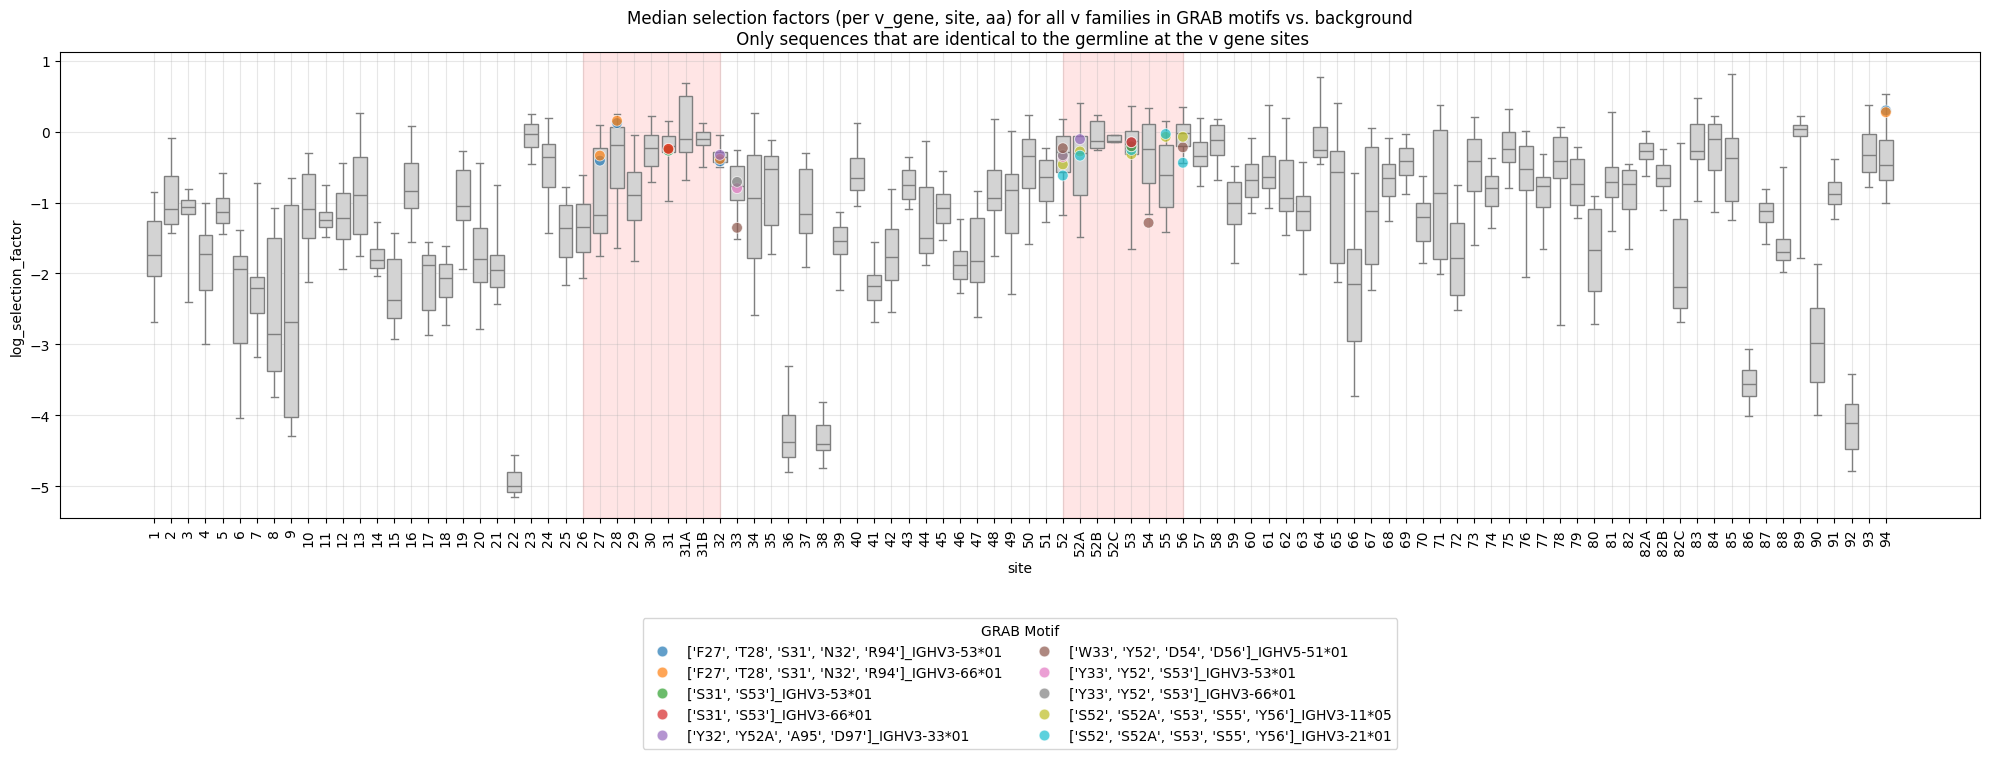

In [3]:
# Load GRAB motifs reference data
grab_motifs_from_paper = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/grab_motifs/grab_motifs_human_ighv_chothia_to_imgt_mapping.csv')
numbering_position_grab = {'chothia':'chothia_site', 'imgt':'imgt_position'}[numbering_scheme]

# Filter only for sequences that are germline at all of the v gene sites

# Step 0: Count all v_genes (without germline filter)
all_v_gene_counts = site_sub_probs_df[['v_gene', 'pcp_index']].drop_duplicates().v_gene.value_counts()
all_frequent_v_genes = all_v_gene_counts[all_v_gene_counts > 50].index

# Step 1: Identify sequences that are germline at ALL sites where we have germline info
def is_fully_germline(group):
    """Check if all non-NaN is_germline_aa values are True"""
    non_nan = group['is_germline_aa'].dropna()
    if len(non_nan) == 0:
        return False  # No germline info available
    return non_nan.all()  # All available sites must be germline

germline_only_mask = site_sub_probs_df.groupby('pcp_index').apply(is_fully_germline)
germline_only_indices = germline_only_mask[germline_only_mask].index.tolist()

# Step 2: Count sequences per v_gene (only among germline-only sequences)
germline_only_data = site_sub_probs_df[site_sub_probs_df.pcp_index.isin(germline_only_indices)]
v_gene_counts = germline_only_data[['v_gene', 'pcp_index']].drop_duplicates().v_gene.value_counts()

print("Total number of sequences:", site_sub_probs_df.pcp_index.nunique())
print(f"Number of v genes with >50 sequences (no germline filter): {len(all_frequent_v_genes)}")
print(f"Number of sequences that are germline at all v gene sites: {len(germline_only_indices)}")
print(f"Number of v genes represented in germline-only sequences: {len(v_gene_counts)}")

# Step 3: Filter and calculate median - only use germline sites from germline-only sequences
median_log_selection_factors = site_sub_probs_df[
    (site_sub_probs_df.pcp_index.isin(germline_only_indices)) &
    (site_sub_probs_df.is_germline_aa == True)  # Only sites that ARE germline
].groupby(['site', 'is_cdr', 'parent_aa', 'v_gene', 'v_family']).log_selection_factor.median().reset_index()

# Step 4: Merge with GRAB motifs
grab_motifs = pd.merge(
    median_log_selection_factors, 
    grab_motifs_from_paper[['v_gene', 'amino_acid', numbering_position_grab, 'Antibody_GRAB_motif_full']].rename(
        columns={'amino_acid': 'parent_aa', numbering_position_grab: 'site'}
    ), 
    on=['v_gene', 'parent_aa', 'site'], 
    how='left'
)

# all v families
ighv3_data = grab_motifs.copy()


ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] = \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'Antibody_GRAB_motif_full'] + '_' + \
    ighv3_data.loc[ighv3_data.Antibody_GRAB_motif_full.notnull(), 'v_gene']

# Convert site to string to ensure categorical treatment
ighv3_data['site'] = ighv3_data['site'].astype(str)

# Sort sites using the antibody site sorting function
sorted_sites = sort_antibody_sites(ighv3_data['site'].unique())

# Separate data into background (null motif) and GRAB motif
grab_data = ighv3_data[ighv3_data.Antibody_GRAB_motif_full.notnull()]

# Create the plot
fig, ax = plt.subplots(figsize=(20, 8))

# Plot boxplot for all data (background distribution per site)
sns.boxplot(data=ighv3_data, x='site', y='log_selection_factor', 
            color='lightgrey', ax=ax, showfliers=False, whis=[5, 95], order=sorted_sites)

# Overlay GRAB motif data as colored scatter points
sns.scatterplot(data=grab_data, x='site', y='log_selection_factor', 
                hue='Antibody_GRAB_motif_full', ax=ax, s=60, zorder=10, palette='tab10', alpha=0.7)

# Add CDR shading
add_cdr_shading(ax, sorted_sites, numbering_scheme=numbering_scheme, chain='heavy', color='red', alpha=0.1)

# put the legend below the plot
ax.legend(title='GRAB Motif', bbox_to_anchor=(0.5, -0.2), loc='upper center', ncol=2)
ax.set_title('Median selection factors (per v_gene, site, aa) for all v families in GRAB motifs vs. background\n Only sequences that are identical to the germline at the v gene sites')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Analysis of GRAB motif completeness and selection factors

def analyze_grab_motif_completeness(site_sub_probs_df, pcp_df, grab_motifs_file, numbering_scheme='imgt'):
    """
    For each GRAB motif, identify sequences that:
    1. Have the complete GRAB motif (all sites with correct amino acids)
    2. Have the motif except for one site that mutated
    
    Then analyze selection factors at GRAB motif sites for both groups.
    
    Parameters:
    -----------
    site_sub_probs_df : pd.DataFrame
        Site-level substitution data
    pcp_df : pd.DataFrame
        Parent-child pair data
    grab_motifs_file : str
        Path to GRAB motifs CSV file
    numbering_scheme : str
        Either 'imgt' or 'chothia'
    """
    
    # Load GRAB motifs reference
    grab_ref = pd.read_csv(grab_motifs_file)
    
    # Select the correct position column based on numbering scheme
    numbering_position_grab = {'chothia':'chothia_site', 'imgt':'imgt_position'}[numbering_scheme]
    
    # Create a mapping of v_gene -> GRAB motifs
    # Group by v_gene and Antibody_GRAB_motif_full to get all sites in each motif
    grab_motifs_dict = {}
    for (v_gene, motif_name), group in grab_ref.groupby(['v_gene', 'Antibody_GRAB_motif_full']):
        # Filter out rows where the numbering position is NaN
        group_filtered = group[group[numbering_position_grab].notna()]
        if len(group_filtered) > 0:
            grab_motifs_dict[(v_gene, motif_name)] = {
                'sites': group_filtered[numbering_position_grab].tolist(),
                'amino_acids': dict(zip(group_filtered[numbering_position_grab], group_filtered['amino_acid']))
            }
    
    # For each pcp (sequence), determine which GRAB motifs it has and which sites are mutated
    results = []
    
    for pcp_idx in tqdm(site_sub_probs_df.pcp_index.unique()):
        pcp_data = site_sub_probs_df[site_sub_probs_df.pcp_index == pcp_idx]
        v_gene = pcp_data.v_gene.iloc[0]
        
        # Get all GRAB motifs for this v_gene
        relevant_motifs = {k: v for k, v in grab_motifs_dict.items() if k[0] == v_gene}
        
        for (motif_v_gene, motif_name), motif_info in relevant_motifs.items():
            sites = motif_info['sites']
            expected_aas = motif_info['amino_acids']
            
            # Check each site in the motif
            motif_status = {}
            for site in sites:
                site_data = pcp_data[pcp_data.site == str(site)]
                if len(site_data) > 0:
                    parent_aa = site_data.parent_aa.iloc[0]
                    expected_aa = expected_aas[site]
                    motif_status[site] = {
                        'has_correct_aa': parent_aa == expected_aa,
                        'parent_aa': parent_aa,
                        'expected_aa': expected_aa,
                        'log_selection_factor': site_data.log_selection_factor.iloc[0] if 'log_selection_factor' in site_data.columns else None
                    }
            
            # Classify the sequence
            correct_sites = [s for s, info in motif_status.items() if info['has_correct_aa']]
            incorrect_sites = [s for s, info in motif_status.items() if not info['has_correct_aa']]
            
            if len(motif_status) == len(sites):  # All sites present in data
                if len(correct_sites) == len(sites):
                    motif_category = 'complete'
                    mutated_site = None
                elif len(correct_sites) == len(sites) - 1:
                    motif_category = 'one_mutation'
                    mutated_site = incorrect_sites[0] if len(incorrect_sites) == 1 else None
                else:
                    motif_category = 'multiple_mutations'
                    mutated_site = None
                
                # Record results for each site in the motif
                for site, site_info in motif_status.items():
                    results.append({
                        'pcp_index': pcp_idx,
                        'v_gene': v_gene,
                        'motif_name': motif_name,
                        'motif_category': motif_category,
                        'mutated_site': mutated_site,
                        'site': site,
                        'parent_aa': site_info['parent_aa'],
                        'expected_aa': site_info['expected_aa'],
                        'has_correct_aa': site_info['has_correct_aa'],
                        'log_selection_factor': site_info['log_selection_factor'],
                        'num_correct_sites': len(correct_sites),
                        'total_motif_sites': len(sites)
                    })
    
    return pd.DataFrame(results)


# Run the analysis
grab_completeness = analyze_grab_motif_completeness(
    site_sub_probs_df,
    pcp_df,
    '/fh/fast/matsen_e/shared/bcr-mut-sel/grab_motifs/grab_motifs_human_ighv_chothia_to_imgt_mapping.csv',
    numbering_scheme=numbering_scheme
)

print("GRAB motif completeness analysis:")
print(grab_completeness.head(20))
print("\nCategories distribution:")
print(grab_completeness.groupby(['v_gene', 'motif_name', 'motif_category']).size())

  0%|          | 0/21745 [00:00<?, ?it/s]

  0%|          | 26/21745 [00:00<01:26, 250.79it/s]

  0%|          | 53/21745 [00:00<01:23, 260.12it/s]

  0%|          | 80/21745 [00:00<01:22, 261.15it/s]

  0%|          | 107/21745 [00:00<01:21, 264.24it/s]

...

100%|█████████▉| 21667/21745 [01:23<00:00, 255.69it/s]

100%|█████████▉| 21694/21745 [01:23<00:00, 258.58it/s]

100%|█████████▉| 21721/21745 [01:23<00:00, 257.88it/s]

100%|██████████| 21745/21745 [01:23<00:00, 259.26it/s]

GRAB motif completeness analysis:
    pcp_index       v_gene                            motif_name  \
0           5  IGHV5-51*01          ['W33', 'Y52', 'D54', 'D56']   
1           5  IGHV5-51*01          ['W33', 'Y52', 'D54', 'D56']   
2           5  IGHV5-51*01          ['W33', 'Y52', 'D54', 'D56']   
3           5  IGHV5-51*01          ['W33', 'Y52', 'D54', 'D56']   
4           6  IGHV5-51*01          ['W33', 'Y52', 'D54', 'D56']   
5           6  IGHV5-51*01          ['W33', 'Y52', 'D54', 'D56']   
6           6  IGHV5-51*01          ['W33', 'Y52', 'D54', 'D56']   
7           6  IGHV5-51*01          ['W33', 'Y52', 'D54', 'D56']   
8          16  IGHV3-21*01  ['S52', 'S52A', 'S53', 'S55', 'Y56']   
9          16  IGHV3-21*01  ['S52', 'S52A', 'S53', 'S55', 'Y56']   
10         16  IGHV3-21*01  ['S52', 'S52A', 'S53', 'S55', 'Y56']   
11         16  IGHV3-21*01  ['S52', 'S52A', 'S53', 'S55', 'Y56']   
12         16  IGHV3-21*01  ['S52', 'S52A', 'S53', 'S55', 'Y56']   
13         17 

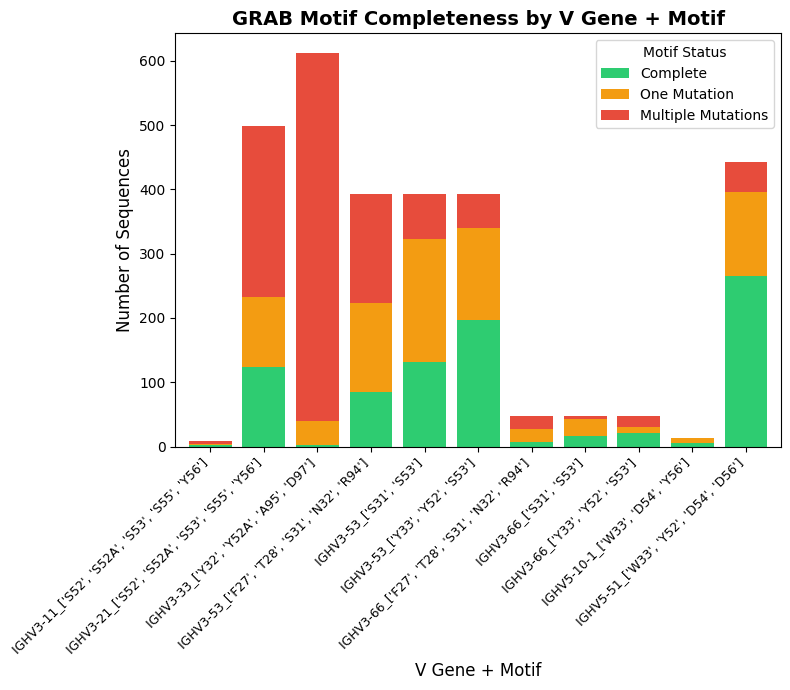

In [5]:

# Plot 1: Overview of GRAB motif completeness across all v_genes
def plot_grab_completeness_overview(grab_completeness):
    """
    Bar plot showing the distribution of complete vs partial GRAB motifs
    Each (v_gene, motif_name) combination is counted separately
    """
    fig, ax = plt.subplots(1, 1, figsize=(8, 7))
    
    # Count by category - group by v_gene AND motif_name
    # First drop duplicates to avoid counting the same pcp_index multiple times per motif
    unique_data = grab_completeness[['v_gene', 'motif_name', 'motif_category', 'pcp_index']].drop_duplicates(
        subset=['v_gene', 'motif_name', 'motif_category', 'pcp_index']
    )
    
    category_counts = unique_data.groupby(['v_gene', 'motif_name', 'motif_category']).pcp_index.nunique().reset_index()
    
    # Create combined label for v_gene + motif (shortened)
    category_counts['v_gene_short'] = category_counts['v_gene'].str.split('*').str[0]
    category_counts['v_gene_motif'] = category_counts['v_gene_short'] + '_' + category_counts['motif_name']
    
    # Plot 1: Stacked bar chart by v_gene+motif
    pivot_data = category_counts.pivot(index='v_gene_motif', columns='motif_category', values='pcp_index').fillna(0)
    
    # Ensure column order: complete, one_mutation, multiple_mutations
    col_order = []
    for col in ['complete', 'one_mutation', 'multiple_mutations']:
        if col in pivot_data.columns:
            col_order.append(col)
    pivot_data = pivot_data[col_order]
    
    pivot_data.plot(kind='bar', stacked=True, ax=ax,
                   color=['#2ecc71', '#f39c12', '#e74c3c'], width=0.8)
    ax.set_title('GRAB Motif Completeness by V Gene + Motif', fontsize=14, fontweight='bold')
    ax.set_xlabel('V Gene + Motif', fontsize=12)
    ax.set_ylabel('Number of Sequences', fontsize=12)
    ax.legend(title='Motif Status', labels=['Complete', 'One Mutation', 'Multiple Mutations'], 
              loc='upper right')
    
    # Fix x-axis labels - rotate and align properly
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.margins(x=0.01)  # Reduce margins
    
    plt.tight_layout()
    return fig

fig1 = plot_grab_completeness_overview(grab_completeness)

Creating 6 subplots for GRAB motifs (min 50 sequences)
Comparing INTACT sites:
  Green: All motif sites intact
  Orange: This site intact, but 1 other site mutated


/loc/scratch/52231999/ipykernel_19656/4024689164.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_sites, rotation=90, fontsize=7)
/loc/scratch/52231999/ipykernel_19656/4024689164.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_sites, rotation=90, fontsize=7)
/loc/scratch/52231999/ipykernel_19656/4024689164.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_sites, rotation=90, fontsize=7)
/loc/scratch/52231999/ipykernel_19656/4024689164.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_sites, rotation=90, fontsize=7)


/loc/scratch/52231999/ipykernel_19656/4024689164.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_sites, rotation=90, fontsize=7)
/loc/scratch/52231999/ipykernel_19656/4024689164.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_sites, rotation=90, fontsize=7)


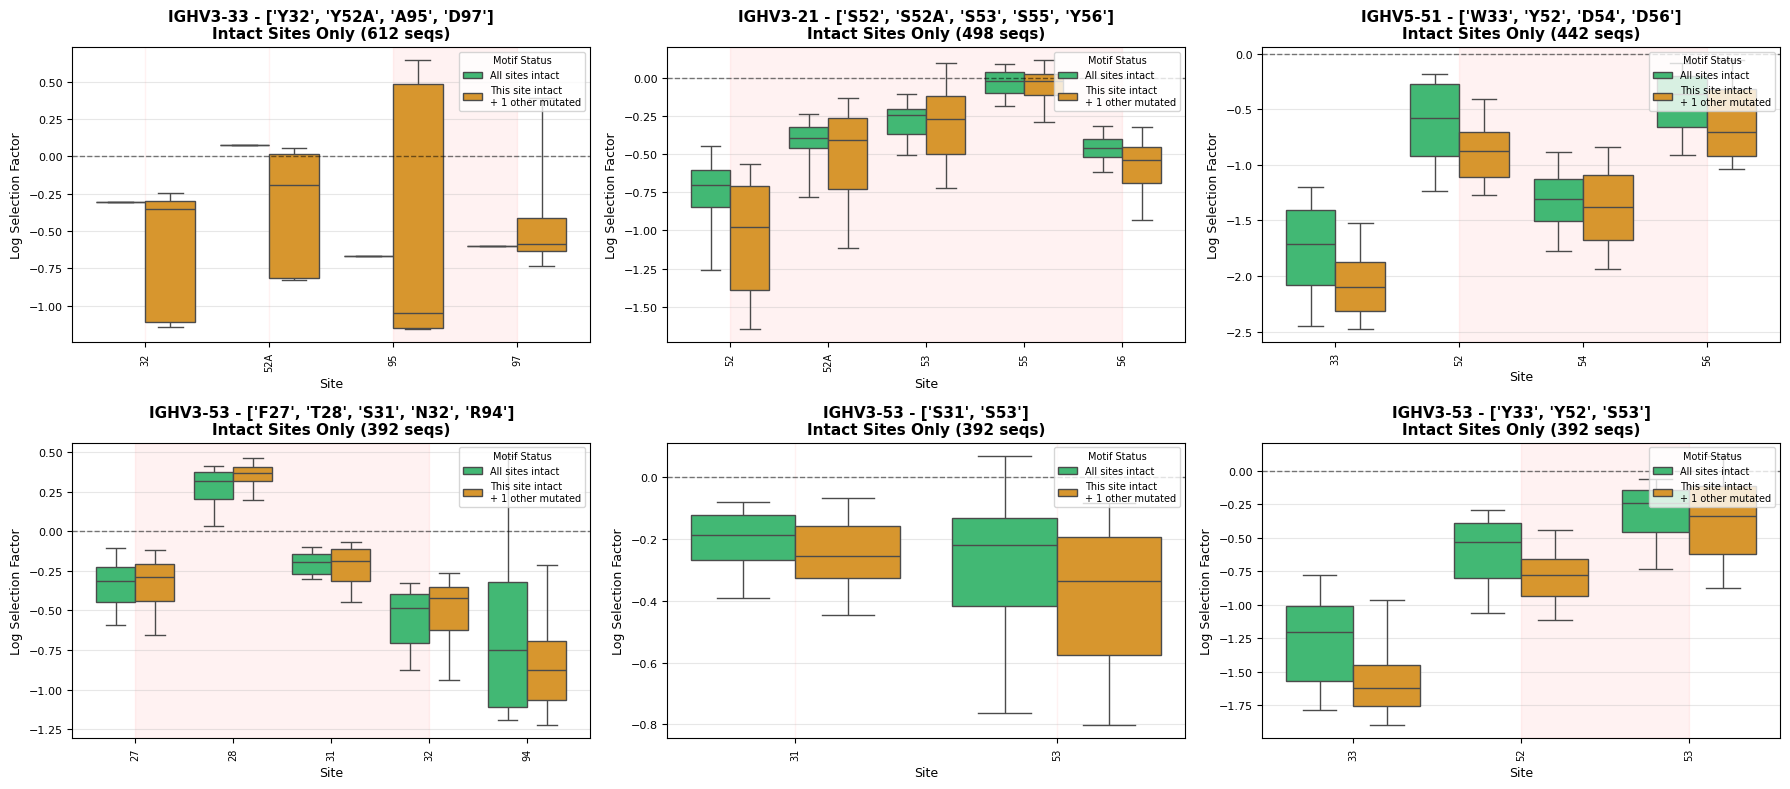

In [6]:
# What would happen if we compared selection factors between cases where the whole grab motif is there, and cases where there is a mutation at another site in the GRAB motif?


def plot_intact_sites_by_motif_status(grab_completeness, numbering_scheme='imgt', min_seqs=50):
    """
    Compare selection factors at INTACT (non-mutated) sites in GRAB motifs:
    - Complete motifs: This site is intact AND all other sites are intact
    - One mutation: This site is intact BUT one other site in the motif is mutated
    
    This tests whether having a mutation elsewhere in the motif affects selection
    at the intact sites.
    
    Parameters:
    -----------
    grab_completeness : pd.DataFrame
        GRAB motif completeness data
    numbering_scheme : str
        'imgt' or 'chothia'
    min_seqs : int
        Minimum number of sequences required to plot a motif (default: 50)
    """
    
    # Get all unique motifs
    unique_motifs = grab_completeness.groupby(['v_gene', 'motif_name']).pcp_index.nunique().reset_index()
    
    # Filter for motifs with at least min_seqs sequences
    unique_motifs = unique_motifs[unique_motifs.pcp_index >= min_seqs]
    
    unique_motifs = unique_motifs.sort_values('pcp_index', ascending=False)  # Sort by number of sequences
    
    n_motifs = len(unique_motifs)
    print(f"Creating {n_motifs} subplots for GRAB motifs (min {min_seqs} sequences)")
    print("Comparing INTACT sites:")
    print("  Green: All motif sites intact")
    print("  Orange: This site intact, but 1 other site mutated")
    
    if n_motifs == 0:
        print(f"No motifs found with at least {min_seqs} sequences")
        return None
    
    # Calculate rows needed for 3 columns
    n_cols = 3
    n_rows = (n_motifs + n_cols - 1) // n_cols  # Ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
    axes = axes.flatten()  # Flatten to 1D array for easier indexing
    
    for idx, (_, row) in enumerate(unique_motifs.iterrows()):
        v_gene = row['v_gene']
        motif_name = row['motif_name']
        count = row['pcp_index']
        
        ax = axes[idx]
        
        motif_data = grab_completeness[
            (grab_completeness.v_gene == v_gene) & 
            (grab_completeness.motif_name == motif_name) &
            (grab_completeness.motif_category.isin(['complete', 'one_mutation']))
        ].copy()
        
        if len(motif_data) == 0:
            ax.axis('off')
            continue
        
        # Sort sites
        sorted_sites = sort_antibody_sites(motif_data.site.astype(str).unique())
        motif_data['site'] = motif_data['site'].astype(str)
        motif_data['mutated_site'] = motif_data['mutated_site'].astype(str)
        
        # For plotting, we focus on INTACT sites only
        # Create a combined dataset for plotting
        plot_data = []
        
        for site in sorted_sites:
            # Complete motifs at this site (site is intact, all other sites intact)
            complete_site = motif_data[
                (motif_data.motif_category == 'complete') & 
                (motif_data.site == site) &
                (motif_data.has_correct_aa == True)  # This site is intact
            ].copy()
            complete_site['category_for_plot'] = 'All sites intact'
            plot_data.append(complete_site)
            
            # One mutation cases where THIS site is INTACT (not the mutated one)
            one_mut_intact = motif_data[
                (motif_data.motif_category == 'one_mutation') & 
                (motif_data.site == site) &
                (motif_data.has_correct_aa == True) &  # This site is intact
                (motif_data.mutated_site != site)  # Mutation is at a DIFFERENT site
            ].copy()
            one_mut_intact['category_for_plot'] = 'Intact + 1 mut'
            plot_data.append(one_mut_intact)
        
        plot_df = pd.concat(plot_data, ignore_index=True)
        
        # Create boxplot with consistent theme
        sns.boxplot(data=plot_df, x='site', y='log_selection_factor', 
                   hue='category_for_plot', 
                   hue_order=['All sites intact', 'Intact + 1 mut'],
                   ax=ax, order=sorted_sites,
                   palette={'All sites intact': '#2ecc71', 'Intact + 1 mut': '#f39c12'},
                   showfliers=False, whis=[5, 95])
        
        # Add CDR shading
        add_cdr_shading(ax, sorted_sites, numbering_scheme=numbering_scheme, 
                       chain='heavy', color='red', alpha=0.05)
        
        # Shortened title for compact view
        ax.set_title(f'{v_gene.split("*")[0]} - {motif_name}\nIntact Sites Only ({count} seqs)', 
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('Site', fontsize=9)
        ax.set_ylabel('Log Selection Factor', fontsize=9)
        ax.set_xticklabels(sorted_sites, rotation=90, fontsize=7)
        ax.tick_params(axis='y', labelsize=8)
        
        # Fix the legend - clearer labels
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, ['All sites intact', 'This site intact\n+ 1 other mutated'], 
                 title='Motif Status', loc='upper right', 
                 fontsize=7, title_fontsize=7)
        
        ax.grid(True, alpha=0.3, axis='y')
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    # Hide any unused subplots
    for idx in range(n_motifs, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    return fig


# Run the plot
fig = plot_intact_sites_by_motif_status(
    grab_completeness,
    numbering_scheme=numbering_scheme,
    min_seqs=50
)
plt.show()